# 第一阶段：探索性数据分析（EDA）

本 Notebook 用于回答三个问题：数据是否可靠、客户流失的整体情况如何、哪些字段与流失存在关联。
运行顺序是：读取数据和检查字段 -> 清洗 TotalCharges -> 计算整体流失率 -> 分组比较合同、使用时长、月费、技术支持和支付方式 -> 绘图 -> 总结业务结论。

这里的分组结果表示‘关联’，不能单独证明某个因素导致客户流失。

## 1. 数据读取与基础检查


In [ ]:
import pandas as pd

# 读取项目使用的原始电信客户数据
df = pd.read_csv('telco_customer_churn.csv')

# 查看前 5 行，快速确认字段名称和数据内容
data_head = df.head()
print(data_head)

# 查看数据集维度，返回值依次为（行数，列数）
data_shape = df.shape
print(data_shape)

# 查看字段类型和非空情况；df.info() 会直接打印结果
df.info()

# 查看所有字段名
data_columns = df.columns
print(data_columns)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## 2. 数据质量检查与清洗


In [2]:
# 每列唯一值数量
print(df.nunique())

# 检查 TotalCharges 中去掉首尾空格后是否为空字符串
total_charges_clean = df["TotalCharges"].astype(str).str.strip()
is_blank_total_charges = total_charges_clean.eq("")
print("空字符串数量：", is_blank_total_charges.sum())

# 查看指定列取值
print(df["Churn"].unique())
print(df["Contract"].unique())
print(df["TechSupport"].unique())


# 筛选 TotalCharges 为空的异常记录，并只查看关键字段
print(df[is_blank_total_charges][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64
空字符串数量： 11
['No' 'Yes']
['Month-to-month' 'One year' 'Two year']
['No' 'Yes' 'No internet service']
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
33

经检查，TotalCharges 为空的11条记录，其 tenure 均为0，可理解为新注册、尚未产生累计费用的客户，因此将 TotalCharges 填充为0，而不是直接删除这些客户。

In [3]:
# 创建清洗副本，后续只修改副本以保留原始数据
df_clean = df.copy()
# tenure 为 0 的新客户尚未产生累计费用，因此把对应的空 TotalCharges 设为 0
df_clean.loc[is_blank_total_charges, 'TotalCharges'] = 0
# 将 TotalCharges 字段转换为数值，供统计和建模使用
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'])
# 验证清洗结果：查看字段类型、缺失值和原空值记录
df_clean.info()
print(df_clean["TotalCharges"].isnull().sum())
print(df_clean.loc[is_blank_total_charges,["customerID", "tenure", "TotalCharges"]])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. 整体流失率分析


In [4]:
# 1. 创建“是否流失”的 True/False 标记
is_churn = (df_clean['Churn'] == 'Yes')
# 2. 布尔值的平均值就是流失客户所占比例
overall_churn_rate = is_churn.mean()
# 3. 按百分比格式输出整体流失率
print('流失率：{:.2%}'.format(overall_churn_rate))

流失率：26.54%


## 4. 合同类型与流失率分析


In [5]:
# 1. 将 True/False 的流失判断加入清洗后的数据表
df_clean["ChurnFlag"] = is_churn

# 2. 按合同类型分组；ChurnFlag 的组内平均值就是该合同类型的流失率
contract_churn_rate = df_clean.groupby('Contract')['ChurnFlag'].mean()
print(contract_churn_rate)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: ChurnFlag, dtype: float64


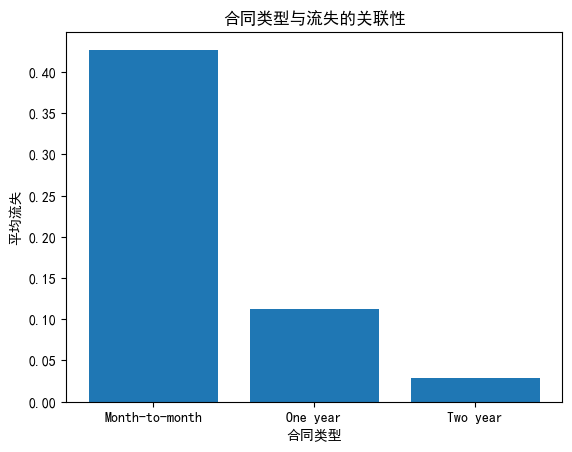

In [6]:
import matplotlib.pyplot as plt
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
# 根据不同合同类型的流失率绘制柱状图
plt.bar(contract_churn_rate.index, contract_churn_rate.values)
plt.xlabel('合同类型')
plt.ylabel('流失率')
plt.title('合同类型与流失的关联性',)
plt.show()

## 5. 使用时长与流失率分析


Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


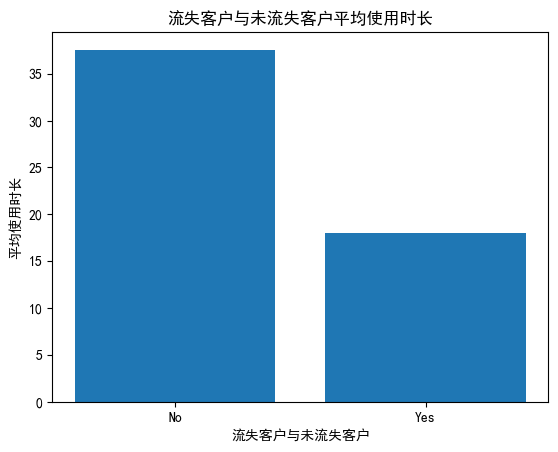

In [7]:
# 比较流失客户与未流失客户的平均使用时长
tenure_by_churn = df_clean.groupby('Churn')['tenure'].mean()
print(tenure_by_churn)

# 绘制柱状图
plt.bar(tenure_by_churn.index, tenure_by_churn.values)
plt.title("流失客户与未流失客户平均使用时长")
plt.xlabel("流失客户与未流失客户")
plt.ylabel("平均使用时长")
plt.show()

## 6. 月费与流失分析


Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


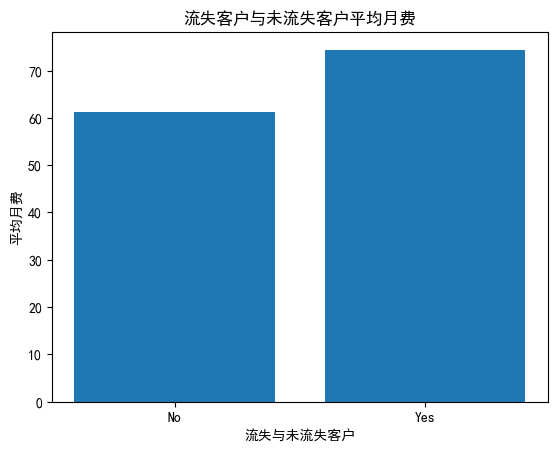

In [8]:
# 比较流失客户与未流失客户的平均月费
avg_monthly_charges_by_churn = df_clean.groupby('Churn')['MonthlyCharges'].mean()
print(avg_monthly_charges_by_churn)

# 绘制柱状图
plt.bar(avg_monthly_charges_by_churn.index, avg_monthly_charges_by_churn.values)
plt.xlabel('流失与未流失客户')
plt.ylabel('平均月费')
plt.title('流失客户与未流失客户平均月费')
plt.show()

## 7. 技术支持服务与流失率分析


TechSupport
No                     0.416355
No internet service    0.074050
Yes                    0.151663
Name: ChurnFlag, dtype: float64


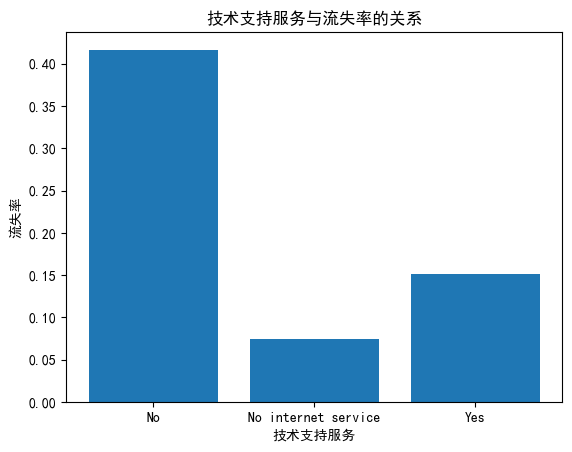

In [9]:
# 分析技术支持服务与流失率的关系
tech_support_churn_rate = df_clean.groupby('TechSupport')['ChurnFlag'].mean()
print(tech_support_churn_rate)

# 绘制柱状图
plt.bar(tech_support_churn_rate.index, tech_support_churn_rate.values)
plt.xlabel('技术支持服务')
plt.ylabel('流失率')
plt.title('技术支持服务与流失率的关系')
plt.show()

## 8. 重复数据检查


In [10]:
# 检查同一客户或完全相同的记录是否重复出现
# 统计完全重复的行数
print(df_clean.duplicated().sum())
# 统计 customerID 重复的数量
print(df_clean['customerID'].duplicated().sum())

0
0


## 9. 支付方式与流失率分析


PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: ChurnFlag, dtype: float64


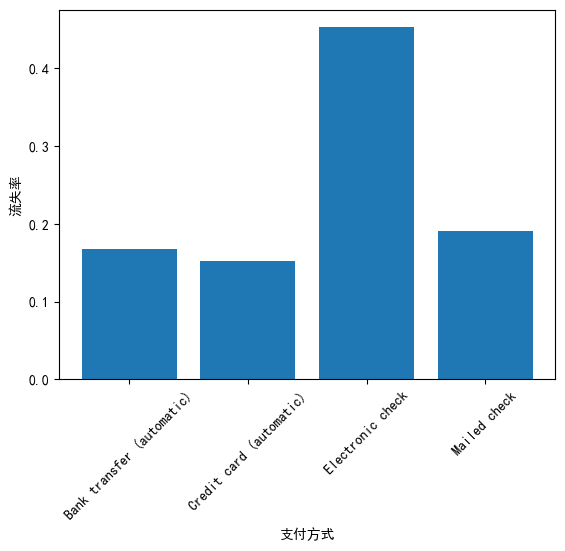

In [11]:
# 统计不同支付方式对应的流失率
payment_method_churn_rate = df_clean.groupby('PaymentMethod')['ChurnFlag'].mean()
print(payment_method_churn_rate)
# 绘制支付方式与流失率的关系图
plt.bar(payment_method_churn_rate.index, payment_method_churn_rate.values)
plt.xlabel('支付方式')
plt.title('支付方式与流失率的关系')
plt.xticks(rotation = 45) 
plt.ylabel('流失率')
plt.show()


使用电子支票的客户流失率最高，为 45.29%，显著高于其他支付方式。自动扣款客户的流失率相对较低，支付方式与客户流失存在明显关联。
针对电子支票客户，考虑提供自动扣款引导或优惠；但仍不能仅凭此结果断言支付方式是唯一原因。

## 10. 客户流失人数分布


Churn
No     5174
Yes    1869
Name: count, dtype: int64


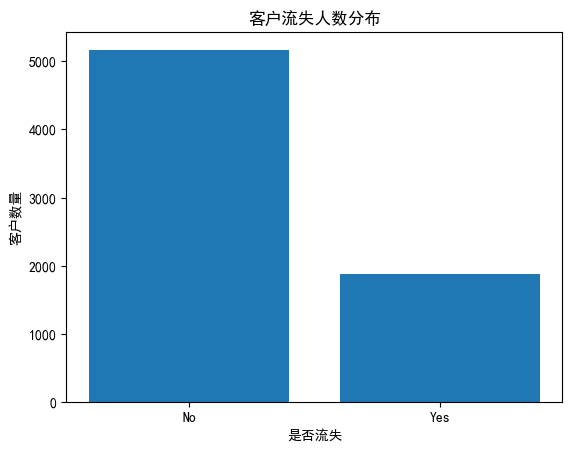

In [12]:
# 统计并绘制 Churn 的人数柱状图

# 取出 Churn 列
churn = df_clean['Churn']
# 使用 value_counts() 统计每个类别出现的次数
churn_counts = churn.value_counts()
print(churn_counts)
# 绘制柱状图
plt.bar(churn_counts.index, churn_counts.values)
plt.xlabel('是否流失')
plt.ylabel('客户数量')
plt.title('客户流失人数分布')
plt.show()

## 11. 阶段一业务结论

1. 综合来看，未流失人数为5174人，流失人数为1869人，整体客户流失率为 26.54%。

2. 月度合同客户的流失率为 42.71%，比整体流失率高 16.17 个百分点。合同周期较短的客户更值得重点关注。

3. 已流失客户的平均使用时长为 17.98 个月，未流失客户为 37.57 个月。使用时长较短与更高流失率存在关联。

4. 未购买技术支持的客户流失率为 41.64%，购买技术支持的客户为 15.17%。没有互联网服务的客户流失率为 7.41%，应作为独立客户群体分析，不能直接等同于“未购买技术支持”。

5. 已流失客户的平均月费为 74.44，未流失客户为 61.27。较高月费与客户流失存在关联。

6. 电子支票客户的流失率为 45.29%，高于其他支付方式；自动信用卡扣款客户的流失率为 15.24%。支付方式与客户流失存在关联，电子支票客户值得重点关注。

以上结论反映变量与流失之间的关联，后续需使用机器学习模型进一步评估各因素的预测作用。